In [1]:
import os
import zipfile
import numpy as np
import pandas as pd
import rasterio
from rasterio.mask import mask
from shapely.ops import unary_union
from shapely.geometry import mapping
from tqdm import tqdm
import os
import glob
import geopandas as gpd
import rasterio
from rasterio.sample import sample_gen
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt

In [2]:
elevation_tif = "Cleaned_dataset/Elevation/algeria_tunisia_clip_processed.tif"


grid_csv = "Cleaned_dataset/grid/algeria_tunisia_grid.csv"
output_csv = "Cleaned_dataset/grid/elevation_grid.csv"

## Extraction des valeurs d'elevation pour chaque point de notre grille 

In [3]:
 
grid_df = pd.read_csv(grid_csv)

 
with rasterio.open(elevation_tif) as src:
    # Extract elevation values for each point
    coords = [(x, y) for x, y in zip(grid_df['longitude'], grid_df['latitude'])]
    elevation_values = [val[0] for val in src.sample(coords)]

 
grid_df['elevation'] = elevation_values

 
grid_df.to_csv(output_csv, index=False)

print(f"Elevation extraction done! Saved to {output_csv}")

Elevation extraction done! Saved to Cleaned_dataset/grid/elevation_grid.csv


In [4]:
print(grid_df.shape)
print(grid_df.head())
print(grid_df.columns)

(82694, 3)
   longitude   latitude  elevation
0  -1.653868  34.000231     1113.0
1  -1.633868  34.000231     1120.0
2  -1.613868  34.000231     1128.0
3  -1.593868  34.000231     1133.0
4  -1.573868  34.000231     1137.0
Index(['longitude', 'latitude', 'elevation'], dtype='object')


In [5]:

print("Number of missing values per column:\n", grid_df.isna().sum())

Number of missing values per column:
 longitude      0
latitude       0
elevation    918
dtype: int64


In [6]:
df = pd.read_csv("Cleaned_dataset/grid/elevation_grid.csv")


In [7]:
def download_naturalearth(output_folder="data"):

    """Download Natural Earth shapefile if not present"""
    os.makedirs(output_folder, exist_ok=True)
    shapefile_path = os.path.join(output_folder, "ne_110m_admin_0_countries.shp")

    if not os.path.exists(shapefile_path):
        print("Downloading Natural Earth shapefile...")

        url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
        
        zip_path = os.path.join(output_folder, "ne_countries.zip")

        r = requests.get(url)
        with open(zip_path, "wb") as f:
            f.write(r.content)

        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(output_folder)
        os.remove(zip_path)
        print(" Natural Earth shapefile downloaded and extracted.")
    else:
        print(" Natural Earth shapefile already available.")
    return shapefile_path


world = gpd.read_file(download_naturalearth())     
world["ADMIN"] = world["ADMIN"].str.strip().str.lower()
north_africa = world[world["ADMIN"].isin(["algeria", "tunisia"])]

 Natural Earth shapefile already available.


C:\Users\melom\AppData\Local\Temp\ipykernel_22080\2188874962.py:29: RuntimeWarning: invalid value encountered in divide
  avg_elev = H / counts


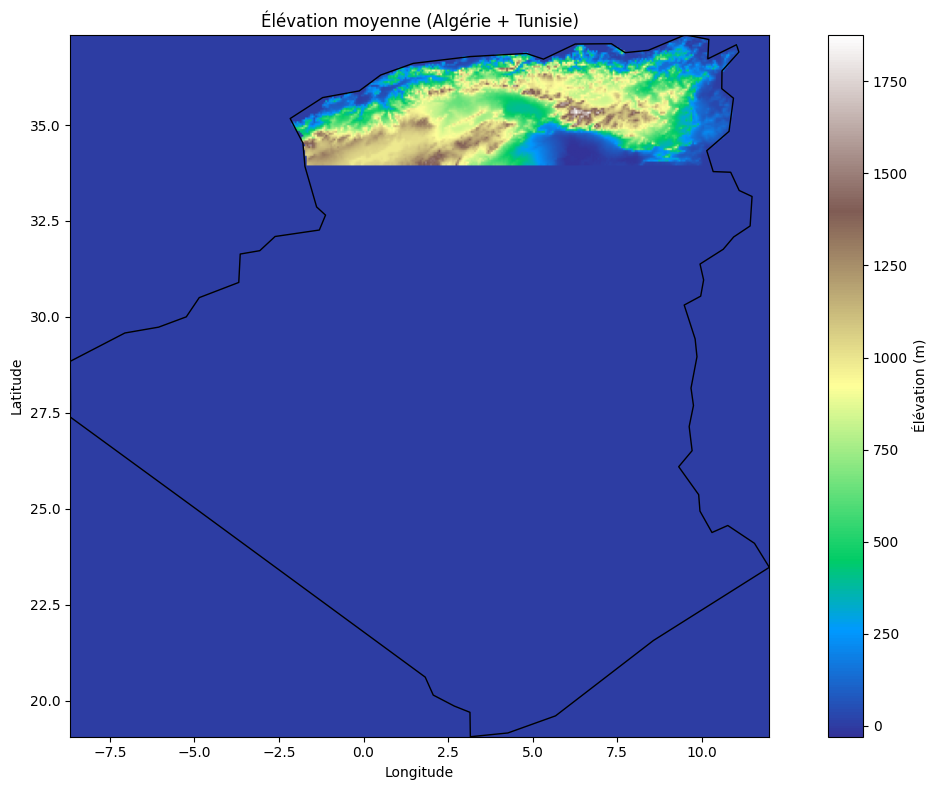

In [8]:

df = pd.read_csv("Cleaned_dataset/grid/elevation_grid.csv")
df = df.dropna(subset=["elevation"])


north_africa_union = north_africa.dissolve()
minx, miny, maxx, maxy = north_africa_union.total_bounds

# Raster resolution (degrees)
res = 0.05  

# Create bins
x_bins = np.arange(minx, maxx + res, res)
y_bins = np.arange(miny, maxy + res, res)

# Weighted sum of elevation per cell
H, xedges, yedges = np.histogram2d(
    df["latitude"], df["longitude"],
    bins=[y_bins, x_bins],
    weights=df["elevation"]
)

# Count points per cell
counts, _, _ = np.histogram2d(
    df["latitude"], df["longitude"],
    bins=[y_bins, x_bins]
)

# Compute average elevation per cell
avg_elev = H / counts
avg_elev = np.nan_to_num(avg_elev)  # replace NaNs with 0

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(
    avg_elev,
    extent=[minx, maxx, miny, maxy],
    origin="lower",
    cmap="terrain",
    aspect="auto"
)

# Overlay Algeria + Tunisia boundaries
north_africa_union.boundary.plot(ax=ax, color="black", linewidth=1)

# Colorbar and labels
plt.colorbar(im, ax=ax, label="Élévation (m)")
ax.set_title("Élévation moyenne (Algérie + Tunisie)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.show()
